# Lab Assignemnt 4


---
_**Team 06**_

Name | Roll Number
---|---
Aditya Prakash Borate| 23110065
Swayam Giridhar Borate | 23110066

---


# Task 1: Setup the Dataset

In [1]:
!pip install datasets

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
# Load the MNIST dataset from Hugging Face
dataset = load_dataset("mnist")

print(dataset)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


In [4]:
# Convert images to NumPy arrays and normalize pixel values to [0,1]
def process_data(dataset):
    images = np.array(dataset["image"]) / 255.0  # Normalize
    images = images.reshape(len(images), -1)  # Flatten to (num_samples, 784)
    labels = np.array(dataset["label"])  # Extract labels
    return images, labels

# Process train and test sets
X_train, y_train = process_data(dataset["train"])
X_test, y_test = process_data(dataset["test"])

# Split the dataset into initial labeled data (200 samples) and an unlabeled pool
num_labeled = 200
num_samples = len(X_train)

# Randomly choose 200 indices for the labeled dataset
labeled_indices = np.random.choice(num_samples, num_labeled, replace=False)

# Create a boolean mask for the labeled data
labeled_mask = np.zeros(num_samples, dtype=bool)
labeled_mask[labeled_indices] = True

# The unlabeled indices are those not selected in the labeled set
unlabeled_indices = np.where(~labeled_mask)[0]  # Invert the mask to get unlabeled indices

# Extract labeled and unlabeled data using the selected indices
X_labeled, y_labeled = X_train[labeled_indices], y_train[labeled_indices]
X_unlabeled, y_unlabeled = X_train[unlabeled_indices], y_train[unlabeled_indices]

# Print dataset sizes
print(f"Total training samples: {len(X_train)}")
print(f"Total testing samples: {len(X_test)}")
print(f"Initial labeled dataset: {len(X_labeled)}")
print(f"Unlabeled pool: {len(X_unlabeled)}")


Total training samples: 60000
Total testing samples: 10000
Initial labeled dataset: 200
Unlabeled pool: 59800


# Task 2: Implement Random Sampling for Active Learning

In [5]:
# Step 1

## Step a: Initialize a Random Forest model
def initialize_model():
    return RandomForestClassifier(random_state=43)

## Step b: Train the model on the initial labeled dataset
def train_model(model, X_labeled, y_labeled):
    model.fit(X_labeled, y_labeled)

In [6]:
# Randomly select a sample from the unlabeled pool
def random_sampling(unlabeled_data):
    random_idx = random.randint(0, len(unlabeled_data) - 1)
    return random_idx

def update_datasets(X_labeled, y_labeled, X_unlabeled, y_unlabeled, selected_idx):
    # Update labeled and unlabeled datasets
    X_selected = X_unlabeled[selected_idx].reshape(1, -1)
    y_selected = y_unlabeled[selected_idx]

    X_labeled = np.vstack((X_labeled, X_selected))
    y_labeled = np.append(y_labeled, y_selected)

    X_unlabeled = np.delete(X_unlabeled, selected_idx, axis=0)
    y_unlabeled = np.delete(y_unlabeled, selected_idx, axis=0)

    return X_labeled, y_labeled, X_unlabeled, y_unlabeled

def active_learning_rs(model_rs, X_labeled, y_labeled, X_unlabeled, y_unlabeled, X_test, y_test, n_iters=20):
    accuracies_rs = []
    for i in range(n_iters):
        selected_idx = random_sampling(X_unlabeled)
        X_labeled, y_labeled, X_unlabeled, y_unlabeled = update_datasets(X_labeled, y_labeled, X_unlabeled, y_unlabeled, selected_idx)

        # Retrain the model
        train_model(model_rs, X_labeled, y_labeled)

        # Check model accuracy
        y_pred = model_rs.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracies_rs.append(accuracy)
        print(f"Iteration {i+1}: Accuracy = {accuracy:.4f}")
    return accuracies_rs

# Initialize and train model
model_rs = initialize_model()
train_model(model_rs, X_labeled, y_labeled)

# Run Active Learning
acc_rs = active_learning_rs(model_rs, X_labeled, y_labeled, X_unlabeled, y_unlabeled, X_test, y_test)

Iteration 1: Accuracy = 0.8021
Iteration 2: Accuracy = 0.7983
Iteration 3: Accuracy = 0.7951
Iteration 4: Accuracy = 0.7977
Iteration 5: Accuracy = 0.7935
Iteration 6: Accuracy = 0.7980
Iteration 7: Accuracy = 0.8062
Iteration 8: Accuracy = 0.8024
Iteration 9: Accuracy = 0.8029
Iteration 10: Accuracy = 0.8105
Iteration 11: Accuracy = 0.8041
Iteration 12: Accuracy = 0.8036
Iteration 13: Accuracy = 0.7968
Iteration 14: Accuracy = 0.7963
Iteration 15: Accuracy = 0.7978
Iteration 16: Accuracy = 0.8029
Iteration 17: Accuracy = 0.8055
Iteration 18: Accuracy = 0.8042
Iteration 19: Accuracy = 0.8055
Iteration 20: Accuracy = 0.8031


# Task 3: : Implement Uncertainty Sampling for Active Learning.

$$
H(x) = - \sum_{i=1}^{N} P(\hat{y}_i \mid x) \log P(\hat{y}_i \mid x)
$$

where

- $( H(x) )$: The entropy (disagreement measure) for instance $( x )$.
- $( x )$: The instance from the unlabeled dataset $( D_u )$ being evaluated.
- $( \hat{y}_i )$: The prediction made by the $( i )$-th model in the committee.
- $( P(\hat{y}_i \mid x) )$: The predicted probability distribution of the $( i )$-th model for instance $( x )$.




In [11]:
# Compute entropy for each sample in the unlabeled pool
def label_entropy_sampling(model_us, unlabeled_data):
    probabilities = model_us.predict_proba(unlabeled_data)  # Get probabilities for each class
    entropies = -np.sum(probabilities * np.log(probabilities + 1e-10), axis=1)  # Compute entropy
    return np.argmax(entropies)  # Select sample with highest entropy

# Active Learning Loop with Uncertainty Sampling
def active_learning_uncertainty(model_us, X_labeled, y_labeled, X_unlabeled, y_unlabeled, X_test, y_test, n_iters=20):
    accuracies_us = []

    for i in range(n_iters):
        # Select the most uncertain sample
        selected_idx = label_entropy_sampling(model_us, X_unlabeled)

        # Update datasets with the selected sample
        X_labeled, y_labeled, X_unlabeled, y_unlabeled = update_datasets(X_labeled, y_labeled, X_unlabeled, y_unlabeled, selected_idx)

        # Retrain the model with the updated labeled dataset
        train_model(model_us, X_labeled, y_labeled)

        # Evaluate the model accuracy on the test set
        y_pred = model_us.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracies_us.append(accuracy)

        # Print the accuracy after every iteration
        print(f"Iteration {i+1}: Test Accuracy = {accuracy:.4f}")

    return accuracies_us

# Initialize and train the model
model_us = initialize_model()
train_model(model_us, X_labeled, y_labeled)

# Run Active Learning with Uncertainty Sampling
acc_us = active_learning_uncertainty(model_us, X_labeled, y_labeled, X_unlabeled, y_unlabeled, X_test, y_test)


Iteration 1: Test Accuracy = 0.8048
Iteration 2: Test Accuracy = 0.8008
Iteration 3: Test Accuracy = 0.8068
Iteration 4: Test Accuracy = 0.8078
Iteration 5: Test Accuracy = 0.7986
Iteration 6: Test Accuracy = 0.8017
Iteration 7: Test Accuracy = 0.8049
Iteration 8: Test Accuracy = 0.8088
Iteration 9: Test Accuracy = 0.8054
Iteration 10: Test Accuracy = 0.8033
Iteration 11: Test Accuracy = 0.8031
Iteration 12: Test Accuracy = 0.8055
Iteration 13: Test Accuracy = 0.8173
Iteration 14: Test Accuracy = 0.8158
Iteration 15: Test Accuracy = 0.8138
Iteration 16: Test Accuracy = 0.8163
Iteration 17: Test Accuracy = 0.8076
Iteration 18: Test Accuracy = 0.8067
Iteration 19: Test Accuracy = 0.8101
Iteration 20: Test Accuracy = 0.8082


# Task 4:  Implement Query-by-Committee for Active Learning

**Query by Committee:**

- Given a committee of models $( \mathcal{C} = \{f_1, f_2, \dots, f_N\} )$, each trained on the labeled dataset $( D_l )$.
- For each unlabeled instance $( x \in D_u )$, the models in the committee generate their predictions $( \hat{y}_1, \hat{y}_2, \dots, \hat{y}_N )$.
- The query is based on the measure of disagreement among the committee members. A commonly used measure is entropy:

$$
H(x) = - \sum_{i=1}^{N} P(\hat{y}_i \mid x) \log P(\hat{y}_i \mid x)
$$


In [8]:
# Initialize a diverse committee of Random Forest models
def initialize_committee(n_models=5):
    random_states = [0, 42, 100, 200, 300]  # Different seeds for diversity
    estimators = [10, 50, 100, 200, 500]  # Different numbers of trees

    return [
        RandomForestClassifier(n_estimators=estimators[i], random_state=random_states[i])
        for i in range(n_models)
    ]

# Train each model on the initial labeled dataset
def train_committee(models, X_labeled, y_labeled):
    for model in models:
        model.fit(X_labeled, y_labeled)

In [9]:
# Vote entropy-based sampling for Query-by-Committee

def vote_entropy_sampling(models, unlabeled_data):
    # Get predictions from all models (shape: n_models x n_samples)
    predictions = np.array([model.predict(unlabeled_data) for model in models])
    n_classes = len(models[0].classes_)
    # For each sample, we count the occurrences of each class predicted by the committee models  by applying bincount
    vote_counts = np.apply_along_axis(lambda x: np.bincount(x, minlength=n_classes), axis=0, arr=predictions)
    vote_proportions = vote_counts / len(models) # Compute vote proportions
    entropies = -np.sum(vote_proportions * np.log(vote_proportions + 1e-10), axis=1) # Compute entropy per sample
    return np.argmax(entropies) #highest uncertainty

# Active learning loop with Query-by-Committee
def active_learning_qbc(committee, X_labeled, y_labeled, X_unlabeled, y_unlabeled, X_test, y_test, n_iters=20):
    accuracies_qbc = []

    for i in range(n_iters):
        # Select most uncertain sample
        selected_idx = vote_entropy_sampling(committee, X_unlabeled)

        # Move selected sample from unlabeled to labeled dataset
        X_labeled, y_labeled, X_unlabeled, y_unlabeled = update_datasets(X_labeled, y_labeled, X_unlabeled, y_unlabeled, selected_idx)

        # Retrain the committee on updated labeled data
        train_committee(committee, X_labeled, y_labeled)

        # Perform majority voting for final predictions
        committee_preds = np.array([model.predict(X_test) for model in committee])
        y_pred = np.apply_along_axis(lambda x: np.bincount(x, minlength=len(committee[0].classes_)).argmax(), axis=0, arr=committee_preds)

        # Evaluate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        accuracies_qbc.append(accuracy)
        print(f"Iteration {i+1}: Accuracy = {accuracy:.4f}")

    return accuracies_qbc

# Initialize and train the diverse committee
committee = initialize_committee()
train_committee(committee, X_labeled, y_labeled)

# Run active learning
acc_qbc = active_learning_qbc(committee, X_labeled, y_labeled, X_unlabeled, y_unlabeled, X_test, y_test)


Iteration 1: Accuracy = 0.8125
Iteration 2: Accuracy = 0.8119
Iteration 3: Accuracy = 0.8109
Iteration 4: Accuracy = 0.8109
Iteration 5: Accuracy = 0.8101
Iteration 6: Accuracy = 0.8108
Iteration 7: Accuracy = 0.8155
Iteration 8: Accuracy = 0.8165
Iteration 9: Accuracy = 0.8195
Iteration 10: Accuracy = 0.8149
Iteration 11: Accuracy = 0.8144
Iteration 12: Accuracy = 0.8124
Iteration 13: Accuracy = 0.8110
Iteration 14: Accuracy = 0.8120
Iteration 15: Accuracy = 0.8145
Iteration 16: Accuracy = 0.8097
Iteration 17: Accuracy = 0.8123
Iteration 18: Accuracy = 0.8148
Iteration 19: Accuracy = 0.8151
Iteration 20: Accuracy = 0.8141


# Task 5: Evaluation & Report

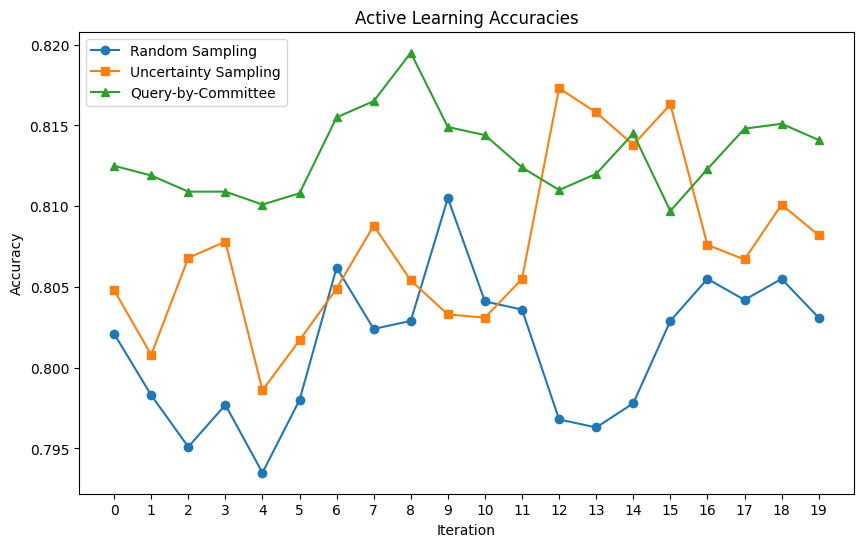

In [12]:
# Plot of the accuracies
plt.figure(figsize=(10, 6))
plt.plot(acc_rs, label='Random Sampling', marker='o')
plt.plot(acc_us, label='Uncertainty Sampling', marker='s')
plt.plot(acc_qbc, label='Query-by-Committee', marker='^')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Active Learning Accuracies')

plt.legend()
plt.xticks(range(20))  # set xticks to integers
plt.show()


## Evaluation & Report

### 1. **Comparison of Final Model Accuracy**
The final model accuracies after 20 iterations for each strategy:

- **Random Sampling**: 0.8031
- **Uncertainty Sampling**: 0.8082
- **Query-by-Committee (QBC)**: 0.8141

QBC outperforms both Random Sampling and Uncertainty Sampling in accuracy.

### 2. **Cost-Effective Accuracy Improvement**
- **QBC**: Most cost-effective, improving accuracy quickly by selecting uncertain samples based on model disagreement.
- **Uncertainty Sampling**: More effective than Random Sampling but slower than QBC.
- **Random Sampling**: Least efficient with gradual improvement.

### 3. **Findings & Limitations**
- **Findings**: QBC provides the best accuracy, while Random Sampling shows the least improvement. Uncertainty Sampling performs moderately and occasionally exceeds QBC but not overall.
- **Limitations**: QBC and Uncertainty Sampling require more computational resources, and their effectiveness depends on the quality of the initial labeled dataset.
